# 参数估计

参数估计要回答的问题是：我们不能观察总体，只能观察样本，那么怎样用样本去估计总体的特征？

本章不再从手工构造的小数组开始，而是直接使用前面已经接触过的表格数据。重点是把 pandas 的数据整理、seaborn 的分布图和统计估计连起来。

## 本章知识点

1. 点估计：用样本均值、样本方差和样本标准差估计总体特征。
2. `describe()`：快速查看连续变量的描述统计。
3. 区间估计：用标准误和 t 分布构造均值的 95% 置信区间。
4. 图形辅助理解：用直方图标出样本均值和置信区间。
5. 分组估计：用 `groupby()` 比较不同组的样本均值。

**本章使用的数据**

本章使用的数据放在工作目录下的 `data` 文件夹中。读取时用相对路径，例如 `data/tips.csv`。

- `data/tips.csv`：餐厅消费和小费数据。一行是一桌顾客的消费记录，包含账单金额、小费、性别、是否吸烟、星期、用餐时段和人数，用于估计平均小费和分组平均小费。[下载](data/tips.csv)
- `data/titanic.csv`：泰坦尼克号乘客数据。一行是一名乘客，包含生存情况、舱位、性别、年龄、票价、登船港口等变量，用于估计乘客平均年龄和票价等总体特征。[下载](data/titanic.csv)

::: {.callout-important}
### 注意
1. 本课程的数据默认放在当前章节 notebook 同级目录下的 `data` 文件夹中。
2. 出现 `FileNotFoundError`，通常是工作目录不对，或者数据文件没有放在 `data` 文件夹中。
3. 本章用到的缺失值处理以“先删除当前分析变量的缺失值”为主，不直接改动原始数据。
:::

## 准备工作

先导入本章需要的包，并读取两张数据表。这里的绘图设置和 seaborn 章节保持一致。


In [41]:
# 导入本章需要的包并读取两张数据表
import pandas as pd  # pandas用于读取和整理表格数据
import matplotlib.pyplot as plt  # pyplot用于创建和调整图形
import seaborn as sns  # seaborn用于绘制统计图形
from scipy import stats  # scipy.stats提供统计估计和检验函数

sns.set_theme()  # 设置seaborn默认主题
plt.rcParams["font.sans-serif"] = ["Hiragino Sans GB", "Microsoft YaHei", "WenQuanYi Micro Hei"]  # 设置中文字体
plt.rcParams["axes.unicode_minus"] = False  # 正常显示负号
%config InlineBackend.figure_formats = ["svg"]  # notebook中使用SVG格式显示图形

tips = pd.read_csv("data/tips.csv")  # read_csv读取CSV文件
titanic = pd.read_csv("data/titanic.csv")  # 相对路径从当前工作目录开始

先看数据结构。参数估计之前，仍然要确认数据里有哪些变量、变量类型是否符合预期、有没有缺失值。

**本节用到的方法/函数**

- `head(n)`：查看前 `n` 行，默认是 5 行。
- `info()`：查看列名、非缺失值数量和数据类型。
- `df[[列名列表]]`：从数据表中选择多列。

In [42]:
# 查看tips数据的前几行
tips.head()  # head默认显示前5行

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [43]:
# 查看titanic数据中本章会用到的主要变量
titanic[["survived", "pclass", "sex", "age", "fare", "embark_town"]].head()  # 双层方括号选择多列

,survived,pclass,sex,age,fare,embark_town
0,0,3,male,22.0,7.2500,Southampton
1,1,1,female,38.0,71.2833,Cherbourg
2,1,3,female,26.0,7.9250,Southampton
3,1,1,female,35.0,53.1000,Southampton
4,0,3,male,35.0,8.0500,Southampton


In [44]:
# 检查tips数据的列名、缺失值和数据类型
tips.info()  # info用于快速查看表结构

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [45]:
# 检查titanic中核心变量的数据类型和缺失情况
titanic[["age", "fare", "sex", "pclass", "embark_town"]].info()  # 先选列再查看结构

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          714 non-null    float64
 1   fare         891 non-null    float64
 2   sex          891 non-null    object 
 3   pclass       891 non-null    int64  
 4   embark_town  889 non-null    object 
dtypes: float64(2), int64(1), object(2)
memory usage: 34.9+ KB


## 点估计

**点估计**是用样本中的一个数来估计总体参数。常见例子包括：

- 用样本均值估计总体均值；
- 用样本方差估计总体方差；
- 用样本比例估计总体比例。

严格说，**估计量**是一个计算规则，例如“用样本均值估计总体均值”；**估计值**是把具体样本代入这个规则后得到的数值。

**本节用到的方法/函数**

- `describe()`：快速查看样本数、均值、标准差、最小值、四分位数和最大值。
- `dropna()`：删除缺失值，避免缺失值影响统计计算。
- `count()`：计算非缺失观测数。
- `mean()`：计算样本均值。
- `std(ddof=1)`：计算样本标准差，`ddof=1` 表示使用 $n-1$ 作为分母。
- `var(ddof=1)`：计算样本方差。
- `min()` / `max()`：计算最小值和最大值。
- `pd.Series({...})`：把多个统计量整理成一列结果。
- `round(位数)`：控制小数位数，便于阅读。

先用 pandas 前面学过的 `describe()` 快速查看连续变量的概况。它适合做第一眼检查，但如果要强调某几个统计量，后面也可以手动整理成更清楚的表。

In [46]:
# 用describe快速查看小费和账单金额的描述统计
tips[["tip", "total_bill"]].describe().round(3)  # describe一次给出常见描述统计量

,tip,total_bill
count,244.000,244.000
mean,2.998,19.786
std,1.384,8.902
min,1.000,3.070
25%,2.000,13.348
50%,2.900,17.795
75%,3.562,24.127
max,10.000,50.810


### 例 1：估计餐厅平均小费

问题：这份样本中，顾客平均给多少小费？

这里 `tip` 是连续变量，可以先用 pandas 计算样本数、均值、标准差和方差。方差和标准差使用 `ddof=1`，这是用样本估计总体方差时常见的自由度调整。

In [47]:
# 计算小费变量的点估计和基本描述统计
tip = tips["tip"].dropna()  # dropna删除当前变量中的缺失值

tip_summary = pd.Series(  # Series把多个统计量整理成一列
    {
        "样本数": tip.count(),  # count计算非缺失观测数
        "样本均值": tip.mean(),  # mean计算样本均值
        "样本标准差": tip.std(ddof=1),  # ddof=1表示使用n-1作为分母
        "样本方差": tip.var(ddof=1),  # var计算样本方差
        "最小值": tip.min(),  # min计算最小值
        "最大值": tip.max(),  # max计算最大值
    }
)

tip_summary.round(3)  # round保留3位小数

样本数      244.000
样本均值       2.998
样本标准差      1.384
样本方差       1.914
最小值        1.000
最大值       10.000
dtype: float64

这说明，在这份样本中，平均小费约为 3 美元。它是总体平均小费的一个点估计值。

### 例 2：估计泰坦尼克号乘客平均年龄

`titanic` 数据中的 `age` 有缺失值。这里先只删除年龄缺失的记录，再估计平均年龄。注意：这是对“有年龄记录的乘客”的估计。

In [48]:
# 计算年龄变量的点估计和基本描述统计
age = titanic["age"].dropna()  # 只删除age这一列中的缺失值

age_summary = pd.Series(  # 用Series整理多个统计结果
    {
        "样本数": age.count(),  # 非缺失年龄记录数
        "样本均值": age.mean(),  # 年龄样本均值
        "样本标准差": age.std(ddof=1),  # 样本标准差使用ddof=1
        "样本方差": age.var(ddof=1),  # 样本方差使用ddof=1
        "最小值": age.min(),  # 最小年龄
        "最大值": age.max(),  # 最大年龄
    }
)

age_summary.round(3)  # 结果保留3位小数

样本数      714.000
样本均值      29.699
样本标准差     14.526
样本方差     211.019
最小值        0.420
最大值       80.000
dtype: float64

## 区间估计

点估计只有一个数，但样本会有抽样误差。**区间估计**用一个范围来表达估计的不确定性。

以总体均值为例，常见的 95% 置信区间可以写成：

$$
\bar{x} \pm t_{\alpha/2, n-1} \times \frac{s}{\sqrt{n}}
$$

其中 $s/\sqrt{n}$ 是样本均值的标准误。样本标准差越大，区间通常越宽；样本量越大，标准误通常越小，区间也会变窄。

更严谨地说，95% 置信水平表示：如果反复抽样并按同样方法构造区间，长期来看约 95% 的区间会覆盖总体参数真值。对于已经算出的某一个区间，我们说“用 95% 的置信水平给出这个区间”。

**本节用到的方法/函数**

- `stats.sem(数据)`：计算样本均值的标准误。
- `stats.t.interval(confidence, df, loc, scale)`：基于 t 分布计算置信区间。
- `confidence`：置信水平，例如 `0.95`。
- `df`：自由度，均值置信区间通常用 `n - 1`。
- `loc`：区间中心，这里是样本均值。
- `scale`：标准误。
- `len(数据)`：计算样本长度。

下面直接把已学过的步骤组合起来：先取出一列数据，再计算均值、标准误，最后用 `stats.t.interval()` 给出 95% 置信区间。

### 平均小费的 95% 置信区间

In [49]:
# 直接计算平均小费的95%置信区间
tip_clean = tips["tip"].dropna()  # 删除小费缺失值
mean_tip = tip_clean.mean()  # 计算样本均值
se_tip = stats.sem(tip_clean)  # sem计算样本均值的标准误
ci_tip = stats.t.interval(  # t.interval计算t分布置信区间
    confidence=0.95,  # 置信水平为95%
    df=len(tip_clean) - 1,  # 自由度为样本数减1
    loc=mean_tip,  # 区间中心为样本均值
    scale=se_tip,  # 区间宽度由标准误决定
)

tip_ci_result = pd.Series(  # 把结果整理成一列
    {
        "样本数": len(tip_clean),
        "均值": mean_tip,
        "标准误": se_tip,
        "置信区间下限": ci_tip[0],
        "置信区间上限": ci_tip[1],
    }
)

tip_ci_result.round(3)  # 保留3位小数

样本数       244.000
均值          2.998
标准误         0.089
置信区间下限      2.824
置信区间上限      3.173
dtype: float64

可以把结果写成：样本平均小费约为 3.00 美元，95% 置信区间约为 2.82 到 3.17 美元。这里的置信区间是“平均小费”的区间，不是单个顾客小费金额通常会落入的范围。

### 平均年龄的 95% 置信区间

In [50]:
# 直接计算乘客平均年龄的95%置信区间
age_clean = titanic["age"].dropna()  # 删除年龄缺失值
mean_age = age_clean.mean()  # 计算年龄样本均值
se_age = stats.sem(age_clean)  # 计算年龄均值的标准误
ci_age = stats.t.interval(  # 基于t分布计算置信区间
    confidence=0.95,  # 置信水平为95%
    df=len(age_clean) - 1,  # 自由度为样本数减1
    loc=mean_age,  # 区间中心为样本均值
    scale=se_age,  # 标准误决定区间宽度
)

age_ci_result = pd.Series(  # 整理输出结果
    {
        "样本数": len(age_clean),
        "均值": mean_age,
        "标准误": se_age,
        "置信区间下限": ci_age[0],
        "置信区间上限": ci_age[1],
    }
)

age_ci_result.round(3)  # 保留3位小数

样本数       714.000
均值         29.699
标准误         0.544
置信区间下限     28.632
置信区间上限     30.766
dtype: float64

## 用图形理解估计

先看小费分布，再在图中标出样本均值和均值的 95% 置信区间。图形能帮助我们看到：个体小费的波动范围远大于“平均小费”的置信区间。

**本节用到的方法/函数**

- `plt.subplots(figsize=(宽, 高))`：创建图形和坐标轴。
- `sns.histplot(data, x, bins, kde, ax)`：绘制直方图，可叠加核密度曲线。
- `ax.axvline(x, ...)`：在指定横轴位置画竖线。
- `ax.set_title()`、`ax.set_xlabel()`、`ax.set_ylabel()`：设置标题和坐标轴名称。
- `ax.legend()`：显示图例。
- `plt.show()`：显示图形。

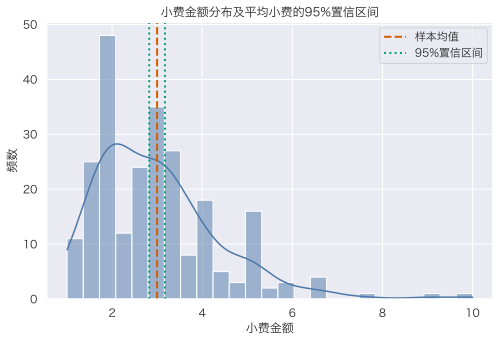

In [51]:
# 绘制小费分布，并标出均值和置信区间
fig, ax = plt.subplots(figsize=(8, 5))  # subplots创建图形和坐标轴

sns.histplot(data=tips, x="tip", bins=25, kde=True, color="#4C78A8", ax=ax)  # histplot画直方图，kde=True叠加密度曲线

ax.axvline(mean_tip, color="#D55E00", linestyle="--", linewidth=2, label="样本均值")  # axvline画竖线
ax.axvline(ci_tip[0], color="#009E73", linestyle=":", linewidth=2, label="95%置信区间")  # 标出区间下限
ax.axvline(ci_tip[1], color="#009E73", linestyle=":", linewidth=2)  # 标出区间上限

ax.set_title("小费金额分布及平均小费的95%置信区间")  # 设置标题
ax.set_xlabel("小费金额")  # 设置横轴名称
ax.set_ylabel("频数")  # 设置纵轴名称
ax.legend()  # 显示图例
plt.show()  # 显示图形

## 分组估计

真实分析中，经常不只估计总体均值，还会比较不同组的均值。例如：不同星期的平均小费是否一样？

这里先用 `groupby()` 计算每个星期的小费样本数、均值和标准差，再用柱状图展示分组均值。分组置信区间和更正式的组间差异判断，留到下一章的假设检验中处理。

**本节用到的方法/函数**

- `groupby("分组列")`：按某个分类变量分组。
- `agg(新列名="统计方法")`：一次计算多个统计量，并指定结果列名。
- `reset_index()`：把索引还原成普通列，方便绘图。
- `sns.barplot(data, x, y, errorbar, ax)`：绘制柱状图。
- `errorbar=None`：不显示自动误差线，只展示分组均值。

In [52]:
# 按星期分组，计算小费的描述统计量
day_tip_summary = tips.groupby("day")["tip"].agg(  # groupby按day分组，agg汇总统计量
    样本数="count",  # count计算每组样本量
    均值="mean",  # mean计算每组均值
    标准差="std",  # std计算每组标准差
)

day_tip_summary.round(3)  # 汇总结果保留3位小数

,样本数,均值,标准差
day,,,
Fri,19,2.735,1.020
Sat,87,2.993,1.631
Sun,76,3.255,1.235
Thur,62,2.771,1.240


下面用柱状图展示不同星期的平均小费。这里不画置信区间，只做分组均值的直观比较。

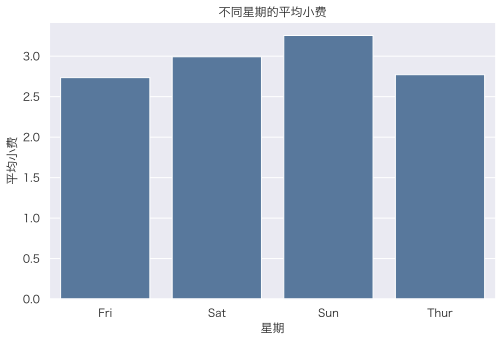

In [53]:
# 绘制不同星期的平均小费柱状图
day_tip_plot = day_tip_summary.reset_index()  # reset_index把day从索引变回普通列

fig, ax = plt.subplots(figsize=(8, 5))  # 创建图形和坐标轴
sns.barplot(data=day_tip_plot, x="day", y="均值", errorbar=None, color="#4C78A8", ax=ax)  # barplot绘制分组均值柱状图

ax.set_title("不同星期的平均小费")  # 设置标题
ax.set_xlabel("星期")  # 设置横轴名称
ax.set_ylabel("平均小费")  # 设置纵轴名称
plt.show()  # 显示图形

## 本章小结

1. 点估计用一个样本统计量估计总体参数，例如用样本均值估计总体均值。
2. 区间估计用一个范围表达抽样不确定性。
3. 标准误衡量“样本均值”本身的波动，不是单个观测值的波动。
4. pandas 的 `mean()`、`std()`、`var()`、`groupby()` 可以完成大部分描述性估计；`scipy.stats` 可以进一步计算置信区间。
5. 图形可以帮助检查分布形态和分组差异，但是否“显著不同”需要进入下一章的假设检验。

## 练习

继续使用 `tips` 和 `titanic` 数据。

**练习 1：账单金额估计**

使用 `tips["total_bill"]`：

1. 计算样本数、均值、标准差和最大值。
2. 计算平均账单金额的 95% 置信区间。
3. 画出账单金额的直方图，并标出均值和置信区间。

**练习 2：票价估计**

使用 `titanic["fare"]`：

1. 计算票价的均值、标准差和 95% 置信区间。
2. 分别按 `class` 计算平均票价及其 95% 置信区间。
3. 用图形比较不同舱位的平均票价。

**练习 3：思考题**

比较“小费金额的标准差”和“平均小费的标准误”。这两个数分别描述什么？为什么标准误通常小于标准差？